# Week 2.2 — Kronecker Assembly, Sparsity, and What Factorisation Costs

As in the first notebook: **run the cells and check the output against the "What you should see"
notes.** The *Optional* section at the end is not required.

Four things:

1. building $A_{2D}$ with Kronecker products, and checking it really is the 5-point stencil;
2. the whole 2D spectrum from the 1D one i.e. the board result 2, verified numerically;
3. what factorisation costs i.e. fill-in measured against the $\mathcal{O}(N^{3/2})$ theorem, and
   wall-clock times with an honest health warning;
4. what storage actually costs, and what reordering does and does achieve.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as sla
from scipy.sparse.csgraph import reverse_cuthill_mckee

## Part 1: assembling $A_{2D}$ with Kronecker products

With row-wise (lexicographic) ordering $p=(j-1)n+i$, the unscaled 2D matrix is

$$T_{2D}=I_n\otimes T+T\otimes I_n,\qquad T=\mathrm{tridiag}(-1,2,-1),\qquad
A_{2D}=\frac{1}{h^2}T_{2D}.$$

$I_n\otimes T$ couples neighbours *within* a grid row ($i\pm1$); $T\otimes I_n$ couples *across*
grid rows ($j\pm1$). Together they are the 5-point stencil. The cell below builds the matrix that
way and, separately, by walking the grid and writing the stencil out by hand — then checks the two
agree exactly.

In [2]:
def poisson_2d(n, scaled=True):
    # A_2D on an n x n interior grid, lexicographic ordering, as a Kronecker sum.
    T = sp.diags([-1.0, 2.0, -1.0], [-1, 0, 1], shape=(n, n), format="csr")
    I = sp.identity(n, format="csr")
    # format="csr" matters: the default lets scipy return BSR, which stores whole
    # dense blocks and so carries explicit zeros. eliminate_zeros drops any that survive
    # the addition, so nnz counts below are the real structural ones.
    T2D = sp.kron(I, T, format="csr") + sp.kron(T, I, format="csr")
    h = 1 / (n + 1)
    A = (T2D / h**2 if scaled else T2D).tocsr()
    A.eliminate_zeros()
    return A


def poisson_2d_by_hand(n):
    # The same matrix, assembled by looping over the grid and writing the stencil.
    N = n * n
    A = sp.lil_matrix((N, N))
    idx = lambda i, j: j * n + i          # p = (j-1)n + i, zero-based
    for j in range(n):
        for i in range(n):
            p = idx(i, j)
            A[p, p] = 4.0
            if i > 0:     A[p, idx(i - 1, j)] = -1.0
            if i < n - 1: A[p, idx(i + 1, j)] = -1.0
            if j > 0:     A[p, idx(i, j - 1)] = -1.0
            if j < n - 1: A[p, idx(i, j + 1)] = -1.0
    return A.tocsr()


n = 6
diff = (poisson_2d(n, scaled=False) - poisson_2d_by_hand(n))
print(f"n = {n}:  max |Kronecker - by hand| = {abs(diff).max() if diff.nnz else 0.0}")

A = poisson_2d(4, scaled=False)
print(f"\nn = 4 (N = 16): nnz = {A.nnz} (expected {5*16 - 4*4}), "
      f"max nonzeros in a row = {np.diff(A.indptr).max()}")
print("\nleading 8x8 block (the first two grid rows):")
print(A.toarray()[:8, :8].astype(int))

n = 6:  max |Kronecker - by hand| = 0.0

n = 4 (N = 16): nnz = 64 (expected 64), max nonzeros in a row = 5

leading 8x8 block (the first two grid rows):
[[ 4 -1  0  0 -1  0  0  0]
 [-1  4 -1  0  0 -1  0  0]
 [ 0 -1  4 -1  0  0 -1  0]
 [ 0  0 -1  4  0  0  0 -1]
 [-1  0  0  0  4 -1  0  0]
 [ 0 -1  0  0 -1  4 -1  0]
 [ 0  0 -1  0  0 -1  4 -1]
 [ 0  0  0 -1  0  0 -1  4]]


**What you should see.** A difference of exactly $0$: the Kronecker sum and the hand-written
stencil are the same matrix. In the printed block: $4$ on the diagonal, $-1$
immediately beside it *except* where a grid row ends (entries $(4,5)$ and $(5,4)$ are zero — those
two grid points are not neighbours, they are opposite ends of adjacent rows), and $-1$ four places
off the diagonal, which is the coupling to the row above and below. At most $5$ nonzeros per row.

## Part 2: the whole 2D spectrum, for free

Board result 2. If $Tv^{(k)}=\theta_k v^{(k)}$ with $\theta_k=4\sin^2\!\bigl(\tfrac{k\pi}{2(n+1)}\bigr)$,
then the mixed-product rule $(M\otimes N)(x\otimes y)=(Mx)\otimes(Ny)$ gives

$$A_{2D}\,\bigl(v^{(k)}\otimes v^{(l)}\bigr)=\frac{\theta_k+\theta_l}{h^2}\,
\bigl(v^{(k)}\otimes v^{(l)}\bigr),$$

so $\kappa(A_{2D})=\dfrac{\theta_n+\theta_n}{\theta_1+\theta_1}=\dfrac{\theta_n}{\theta_1}=\kappa(T)$.

In [3]:
n = 8
h = 1 / (n + 1)
A = poisson_2d(n).toarray()

theta = 4 * np.sin(np.arange(1, n + 1) * np.pi / (2 * (n + 1)))**2
predicted = np.sort(np.add.outer(theta, theta).ravel() / h**2)
computed = np.sort(np.linalg.eigvalsh(A))

print(f"n = {n} (N = {n*n} eigenvalues)")
print(f"max |computed - predicted| = {np.max(np.abs(computed - predicted)):.3e}")
print(f"all eigenvalues positive?    {np.all(computed > 0)}   -> SPD")

T = sp.diags([-1.0, 2.0, -1.0], [-1, 0, 1], shape=(n, n)).toarray()
lam_T = np.linalg.eigvalsh(T)
print(f"\nkappa(A_2D) = {computed[-1] / computed[0]:.6f}")
print(f"kappa(T)    = {lam_T[-1] / lam_T[0]:.6f}   <- the same number")

# And the eigenvector claim: v^(k) tensor v^(l) really is an eigenvector.
v = np.linalg.eigh(T)[1]
w = np.kron(v[:, 2], v[:, 5])
print(f"\nresidual ||A(v2 x v5) - lambda (v2 x v5)|| = "
      f"{np.linalg.norm(A @ w - (theta[2] + theta[5]) / h**2 * w):.3e}")

n = 8 (N = 64 eigenvalues)
max |computed - predicted| = 4.547e-13
all eigenvalues positive?    True   -> SPD

kappa(A_2D) = 32.163437
kappa(T)    = 32.163437   <- the same number

residual ||A(v2 x v5) - lambda (v2 x v5)|| = 7.038e-14


**What you should see.** The $64$ computed eigenvalues match $(\theta_k+\theta_l)/h^2$ to round-off,
all are positive, and $\kappa(A_{2D})$ equals $\kappa(T)$ to six decimals. The 2D problem inherits
the 1D condition number *as a function of $n$* — but there are now $N=n^2$ unknowns, so
$\kappa=\mathcal{O}(N)$ in 2D against $\mathcal{O}(N^2)$ in 1D. Same $h^{-2}$ law, read through a
different $N$.

## Part 3: what the band and the pattern actually cost

Three ways to solve the same system:

| | what it exploits | work |
|---|---|---|
| `numpy.linalg.solve` | nothing | $\mathcal{O}(N^3)$ |
| `scipy.linalg.solveh_banded` | the band, $b\approx n=\sqrt N$ | $\mathcal{O}(Nb^2)=\mathcal{O}(N^2)$ |
| `scipy.sparse.linalg.splu` | the pattern, with a fill-reducing ordering | below $\mathcal{O}(N^2)$ |

Wall-clock time is a poor way to check those exponents on a laptop since the problems that fit are too
small, and a well-tuned LAPACK routine is limited by memory bandwidth rather than by flops. So
measure the thing the theory actually predicts and that no amount of tuning can change: the number
of nonzeros in the factors. Board result 3 says a matrix of half-bandwidth $b$ factorises within its
band, so $L$ and $U$ together hold $\mathcal{O}(Nb)=\mathcal{O}(N^{3/2})$ entries and the work is
$\mathcal{O}(Nb^2)=\mathcal{O}(N^2)$.

In [4]:
fill_rows = []
for n in [10, 20, 30, 40, 60, 80, 120, 160]:
    A = poisson_2d(n).tocsc()
    N = n * n
    # diag_pivot_thresh=0 turns pivoting off: the matrix is SPD, so it is safe, and it
    # lets us see the fill the ordering alone produces.
    nat = spla.splu(A, permc_spec="NATURAL", diag_pivot_thresh=0.0)
    red = spla.splu(A, permc_spec="COLAMD", diag_pivot_thresh=0.0)
    fill_rows.append((n, N, A.nnz, nat.L.nnz + nat.U.nnz, red.L.nnz + red.U.nnz))

print(f"{'n':>5} {'N':>7} {'nnz(A)':>9} {'fill: natural':>14} {'fill: COLAMD':>13} {'N^1.5':>10}")
for n, N, nnz, f_nat, f_red in fill_rows:
    print(f"{n:>5} {N:>7} {nnz:>9} {f_nat:>14} {f_red:>13} {N**1.5:>10.0f}")

Ns = np.array([r[1] for r in fill_rows], float)
for k, name in [(3, "natural"), (4, "COLAMD ")]:
    y = np.array([r[k] for r in fill_rows], float)
    slope = np.polyfit(np.log(Ns[-4:]), np.log(y[-4:]), 1)[0]
    print(f"\nfitted exponent, {name}: fill ~ N^{slope:.3f}")

    n       N    nnz(A)  fill: natural  fill: COLAMD      N^1.5
   10     100       460           2018          1526       1000
   20     400      1920          16038         10048       8000
   30     900      4380          54058         30338      27000
   40    1600      7840         128078         64902      64000
   60    3600     17760         432118        179720     216000
   80    6400     31680        1024158        370282     512000
  120   14400     71520        3456238       1007660    1728000
  160   25600    127360        8192318       2036562    4096000

fitted exponent, natural: fill ~ N^1.500

fitted exponent, COLAMD : fill ~ N^1.237


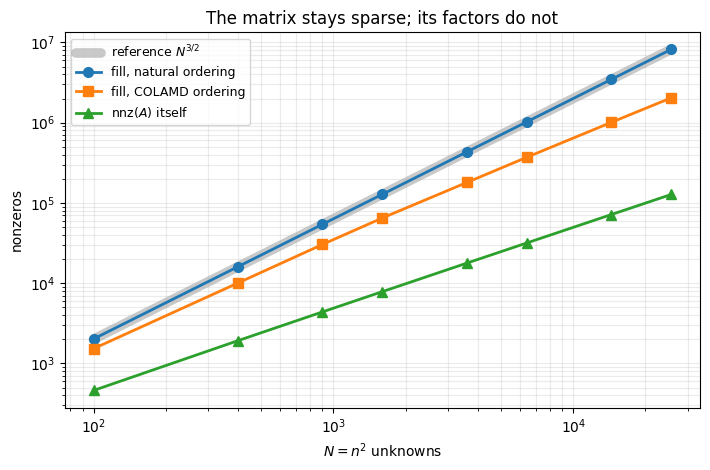

In [5]:
f_nat = np.array([r[3] for r in fill_rows], float)
f_red = np.array([r[4] for r in fill_rows], float)
nnzA = np.array([r[2] for r in fill_rows], float)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
# The reference goes on FIRST, thick and pale, so the measured curve can sit on top of
# it: the natural-ordering fill lands on the theory line, which is easier to see as a
# halo than as a dashed line hidden underneath.
ax.loglog(Ns, f_nat[-1] * (Ns / Ns[-1])**1.5, "-", color="0.62", lw=7, alpha=0.55,
          solid_capstyle="round", zorder=1, label=r"reference $N^{3/2}$")
ax.loglog(Ns, f_nat, "-o", lw=2, ms=7, zorder=3, label="fill, natural ordering")
ax.loglog(Ns, f_red, "-s", lw=2, ms=7, zorder=3, label="fill, COLAMD ordering")
ax.loglog(Ns, nnzA, "-^", lw=2, ms=7, zorder=3, label="nnz($A$) itself")

ax.set_xlabel("$N = n^2$ unknowns")
ax.set_ylabel("nonzeros")
ax.set_title("The matrix stays sparse; its factors do not")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

**What you should see.** The natural-ordering fill sits on the $N^{3/2}$ reference line and the
fitted exponent comes out at $1.500$. COLAMD fits at about $1.24$: the fill-reducing ordering genuinely changes the exponent, not just the constant. And $\mathrm{nnz}(A)$ itself grows like $N$, a straight line of slope $1$ far below both.

That gap between the bottom line and the ones above it *is* the fill-in problem. The matrix has
$5$ nonzeros per row at every size; at $N=25600$ its factors have about $320$.

Now the wall-clock times, with the caveat above firmly in mind.

In [6]:
def to_banded_upper(A, b):
    # Upper-triangular banded storage for solveh_banded: ab[b + i - j, j] = A[i, j], i <= j.
    A = A.tocoo()
    ab = np.zeros((b + 1, A.shape[0]))
    m = A.col >= A.row
    ab[b + A.row[m] - A.col[m], A.col[m]] = A.data[m]
    return ab


def timeit(f, repeats=3):
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter()
        f()
        best = min(best, time.perf_counter() - t0)
    return best


ns_dense = [10, 20, 30, 40, 60]

print(f"{'n':>5} {'N':>7} {'sparse (s)':>12} {'banded (s)':>12} {'dense (s)':>11} {'dense MB':>10}")
for n in [10, 20, 30, 40, 60, 80, 120, 160]:
    A = poisson_2d(n)
    N = n * n
    rhs = np.ones(N)
    t_sp = timeit(lambda: spla.spsolve(A.tocsc(), rhs))
    ab = to_banded_upper(A, n)
    t_ba = timeit(lambda: sla.solveh_banded(ab, rhs))
    if n in ns_dense:
        Ad = A.toarray()
        t_de = f"{timeit(lambda: np.linalg.solve(Ad, rhs)):11.4f}"
    else:
        t_de = "        ---"
    print(f"{n:>5} {N:>7} {t_sp:>12.4f} {t_ba:>12.4f} {t_de} {N*N*8/1e6:>10.1f}")

print(f"\nA dense matrix at n = 120 would need {(120**2)**2 * 8 / 1e9:.2f} GB just to store.")

    n       N   sparse (s)   banded (s)   dense (s)   dense MB
   10     100       0.0003       0.0000      0.0001        0.1
   20     400       0.0009       0.0001      0.0007        1.3
   30     900       0.0013       0.0002      0.0046        6.5
   40    1600       0.0017       0.0004      0.0167       20.5
   60    3600       0.0045       0.0012      0.2081      103.7
   80    6400       0.0082       0.0023         ---      327.7
  120   14400       0.0220       0.0074         ---     1658.9
  160   25600       0.0451       0.0194         ---     5242.9

A dense matrix at n = 120 would need 1.66 GB just to store.


**What you should see.** Dense is the slowest at every size where it runs at all, by a widening
margin, and then it simply stops: at $n=120$ the array alone is about $1.7$ GB. Sparse and banded
are both fast and close to each other, and *neither* shows its asymptotic exponent here — at these
sizes both are dominated by constants and memory traffic, and `solveh_banded` may well beat
`spsolve` because LAPACK's banded kernel is very well tuned while `spsolve` carries Python overhead.

## Part 4: storage and reordering

First the storage arithmetic of the third concept check, measured rather than estimated: the
5-point Laplacian on a $1000\times1000$ grid, $N=10^6$, in CSR with `float64` values and `int32`
indices.

In [7]:
A = poisson_2d(1000).tocsr()
A.indices = A.indices.astype(np.int32)
A.indptr = A.indptr.astype(np.int32)

data_mb = A.data.nbytes / 1e6
ind_mb = A.indices.nbytes / 1e6
ptr_mb = A.indptr.nbytes / 1e6
print(f"N = {A.shape[0]:,}   nnz = {A.nnz:,}  (~{A.nnz / A.shape[0]:.1f} per row)")
print(f"  values   (float64): {data_mb:6.1f} MB")
print(f"  col_ind  (int32)  : {ind_mb:6.1f} MB")
print(f"  row_ptr  (int32)  : {ptr_mb:6.1f} MB")
print(f"  total             : {data_mb + ind_mb + ptr_mb:6.1f} MB")
print(f"\nthe same matrix dense : {A.shape[0]**2 * 8 / 1e12:.0f} TB")
print(f"its LU factors, natural ordering, ~O(N^1.5) entries: "
      f"{A.shape[0]**1.5 * 8 / 1e9:.0f} GB")
del A

N = 1,000,000   nnz = 4,996,000  (~5.0 per row)
  values   (float64):   40.0 MB
  col_ind  (int32)  :   20.0 MB
  row_ptr  (int32)  :    4.0 MB
  total             :   64.0 MB

the same matrix dense : 8 TB
its LU factors, natural ordering, ~O(N^1.5) entries: 8 GB


**What you should see.** About $40 + 20 + 4 = 64$ MB (it fits on a a laptop) against $8$ TB dense. Sparsity is worth a factor of $10^5$. But notice the last line: the *factors* of that same matrix need
about $8$ GB in the natural ordering. Sparse storage is cheap; sparse **factorisation** is not, and
that is what reordering is for. Now the reordering itself. Reverse Cuthill–McKee shrinks the half-bandwidth by renumbering the
unknowns. 

In [9]:
def half_bandwidth(A):
    A = A.tocoo()
    return int(np.max(np.abs(A.row - A.col)))


def chol_fill(A):
    # Number of nonzeros in the Cholesky factor (dense factorisation, small n only).
    L = np.linalg.cholesky(A.toarray())
    return int((np.abs(L) > 1e-12).sum())


n = 30
A_nat = poisson_2d(n)
N = n * n

rng = np.random.default_rng(0)
p = rng.permutation(N)
A_rand = A_nat[p][:, p]

q = reverse_cuthill_mckee(sp.csr_matrix(A_rand), symmetric_mode=True)
A_rcm = A_rand[q][:, q]

tri = N * (N + 1) // 2
print(f"n = {n}, N = {N}, nnz = {A_nat.nnz}  (identical for all three orderings)")
print(f"a full lower triangle would be {tri} entries\n")
print(f"{'ordering':>14} {'half-bandwidth b':>18} {'nnz in chol(A)':>16} {'% of full':>11}")
for name, M in [("natural", A_nat), ("random", A_rand), ("RCM of random", A_rcm)]:
    f = chol_fill(M)
    print(f"{name:>14} {half_bandwidth(M):>18} {f:>16} {f/tri:>10.1%}")

n = 30, N = 900, nnz = 4380  (identical for all three orderings)
a full lower triangle would be 405450 entries

      ordering   half-bandwidth b   nnz in chol(A)   % of full
       natural                 30            26980       6.7%
        random                899            55648      13.7%
 RCM of random                 30            19315       4.8%


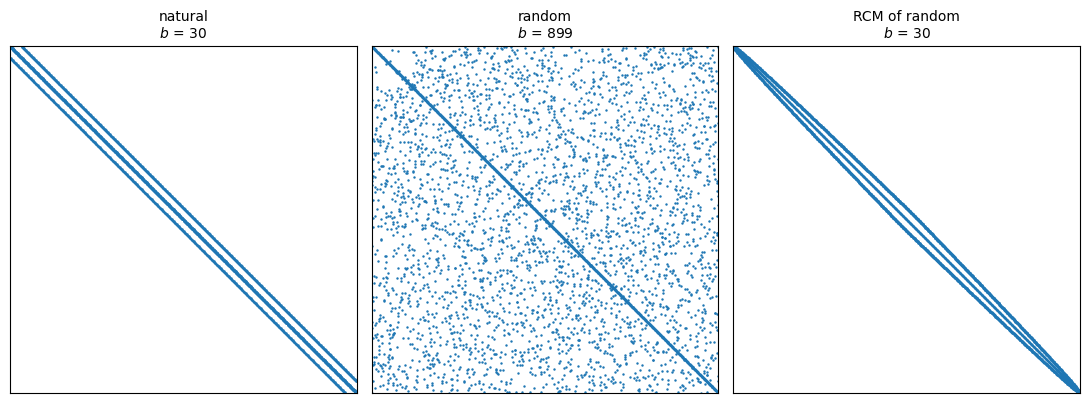

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.9))
for ax, (name, M) in zip(axes, [("natural", A_nat), ("random", A_rand), ("RCM of random", A_rcm)]):
    ax.spy(M, markersize=0.7, color="C0")
    ax.set_title(f"{name}\n$b$ = {half_bandwidth(M)}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

**What you should see.** All three matrices hold the same $4260$ nonzeros and have the same
eigenvalues since a symmetric permutation $PAP^\top$ is a similarity transformation, so nothing
*mathematical* has changed. What changes is where the nonzeros sit, and what that costs to
factorise:

- **natural**: $b=30=n$, a tight band, about $27{,}000$ nonzeros in the Cholesky factor;
- **random**: $b$ almost $N$, nonzeros scattered, and the fill roughly **doubles**;
- **RCM of random**: $b$ back to $30$, and the fill back below the natural ordering's.

Three conclusions, and the last is the one that gets forgotten.

- Fill-in is a property of the *ordering*, not of the matrix. Same operator, same spectrum, twice
  the work.
- RCM recovers locality when the numbering has lost it — which is the situation an unstructured
  mesh generator hands you. Here it even trims a little off the natural ordering.
- But it does not change the *class*. Every ordering above is still $\mathcal{O}(N^{3/2})$ fill and
  $\mathcal{O}(N^2)$ work; RCM shrinks the constant. 

## Optional

Not required.

- Replace `reverse_cuthill_mckee` with a nested-dissection ordering (`scipy` has none built in;
  `metis` or `scikit-sparse` do) and compare the fill against the two above.
- Time `spsolve` against a few hundred iterations of `scipy.sparse.linalg.cg` on the same system.
  Per iteration CG costs one sparse mat-vec, $\mathcal{O}(N)$ — but how many iterations does it
  need, and how does that grow with $n$? (Week 5 answers this; the numbers are visible now.)
- Build $A_{3D}=I\otimes I\otimes T+I\otimes T\otimes I+T\otimes I\otimes I$ and check that
  $\kappa$ still grows like $n^2$ while the bandwidth now grows like $n^2$, not $n$.